In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Regression Models
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor
from sklearn.ensemble import( RandomForestRegressor,
GradientBoostingRegressor,
AdaBoostRegressor
)

#Evaluation Metrics

from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [8]:
df = pd.read_csv("/content/house_price_regression_dataset - house_price_regression_dataset (2).csv")

#Display first 5 rows
print(df.head(5))

# Diagnose: List files in /content/ to check for the CSV file
!ls -F /content/

   Square_Footage  Num_Bedrooms  ...  Neighborhood_Quality   House_Price
0            1360             2  ...                     5  2.623829e+05
1            4272             3  ...                     6  9.852609e+05
2            3592             1  ...                     9  7.779774e+05
3             966             1  ...                     8  2.296989e+05
4            4926             2  ...                     8  1.041741e+06

[5 rows x 8 columns]
 drive/
'house_price_regression_dataset - house_price_regression_dataset (2).csv'
 sample_data/


In [11]:
print(df.columns.tolist())

['SquareFootage', 'Bedrooms', 'Bathrooms','AgeYears','DistanceToCenterMiles','Price']

['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built', 'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price']


['SquareFootage',
 'Bedrooms',
 'Bathrooms',
 'AgeYears',
 'DistanceToCenterMiles',
 'Price']

In [13]:
TARGET_COLUMN = "House_Price"

x=df.drop(TARGET_COLUMN,axis=1)
y=df[TARGET_COLUMN]

print(x.head())
print(y.head())

   Square_Footage  Num_Bedrooms  ...  Garage_Size  Neighborhood_Quality
0            1360             2  ...            0                     5
1            4272             3  ...            1                     6
2            3592             1  ...            0                     9
3             966             1  ...            1                     8
4            4926             2  ...            0                     8

[5 rows x 7 columns]
0    2.623829e+05
1    9.852609e+05
2    7.779774e+05
3    2.296989e+05
4    1.041741e+06
Name: House_Price, dtype: float64


In [14]:
x=pd.get_dummies(x,drop_first=True)


In [15]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [16]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


In [17]:
models={
    "LinearRegression":LinearRegression(),
    "Ridge":Ridge(),
    "Lasso":Lasso(),
    "KNN Regressor":KNeighborsRegressor(),
    "Decision Tree":DecisionTreeRegressor(random_state=42),
    "Random Forest":RandomForestRegressor(random_state=42),
    "Gradient Boosting":GradientBoostingRegressor(random_state=42),
     "ExtraTreeRegressor":ExtraTreeRegressor(random_state=42),
    "AdaBoost":AdaBoostRegressor(random_state=42),
    "SVR":SVR()
}



In [21]:
results = []

for name, model in models.items():

  # Models requiring scaled data

  if name in [
      "LinearRegression",
      "Ridge",
      "Lasso",
      "KNN Regressor",
      "SVR"
  ]:
    model.fit(x_train,y_train)
    pred = model.predict(x_test)
  else:
    model.fit(x_train,y_train)
    pred=model.predict(x_test)

    mae = mean_absolute_error(y_test,pred)
    mse = mean_squared_error(y_test,pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test,pred)

    results.append([name,mae,mse,rmse,r2])

In [23]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score"
    ]
)
results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)
print(results_df)

                Model           MAE           MSE          RMSE  R2 Score
2   Gradient Boosting  12309.085776  2.250064e+08  15000.213468  0.996509
1       Random Forest  16119.618569  3.963351e+08  19908.165812  0.993851
0       Decision Tree  25025.543209  1.042815e+09  32292.649551  0.983822
4            AdaBoost  26265.614409  1.063799e+09  32615.931547  0.983496
3  ExtraTreeRegressor  28464.801409  1.242074e+09  35243.073314  0.980731


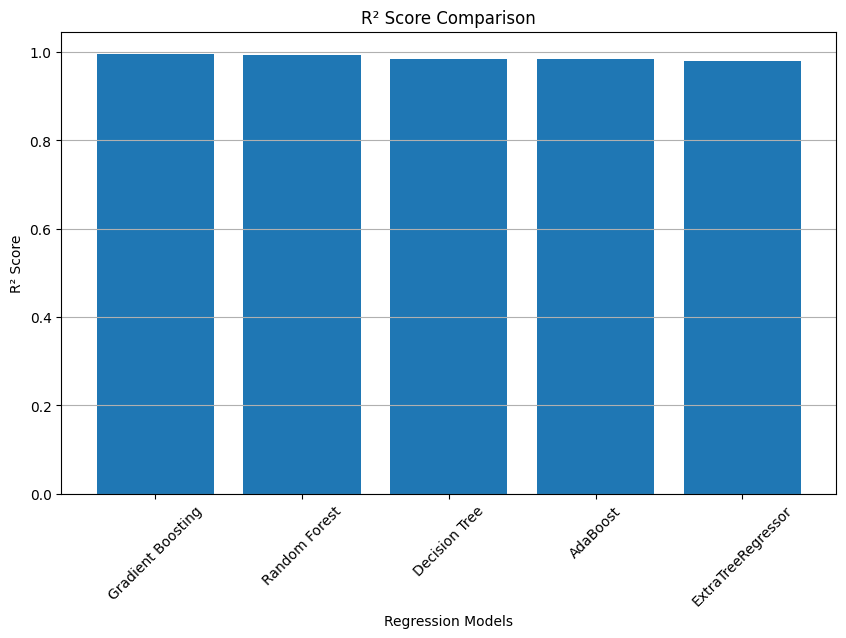

In [28]:
import matplotlib.pyplot as plt

# Sort by R² Score
results_df = results_df.sort_values(by="R2 Score", ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["R2 Score"])
plt.title("R² Score Comparison")
plt.xlabel("Regression Models")
plt.ylabel("R² Score")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

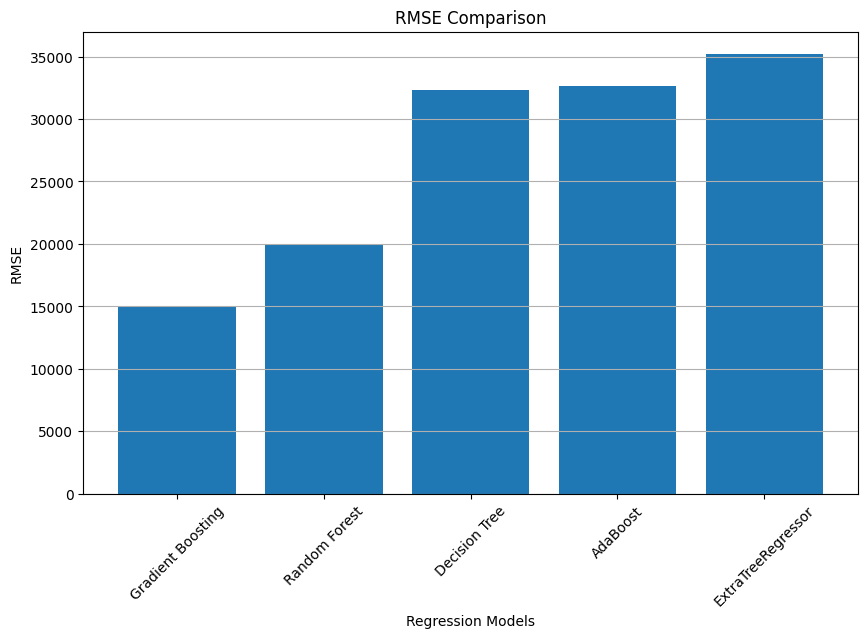

In [32]:
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("RMSE Comparison")
plt.xlabel("Regression Models")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

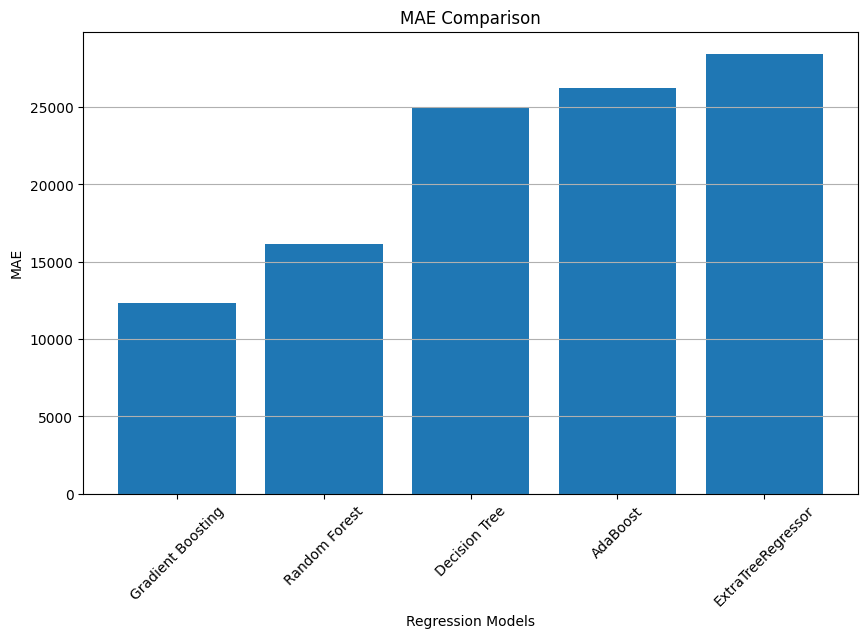

In [33]:
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["MAE"])
plt.title("MAE Comparison")
plt.xlabel("Regression Models")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

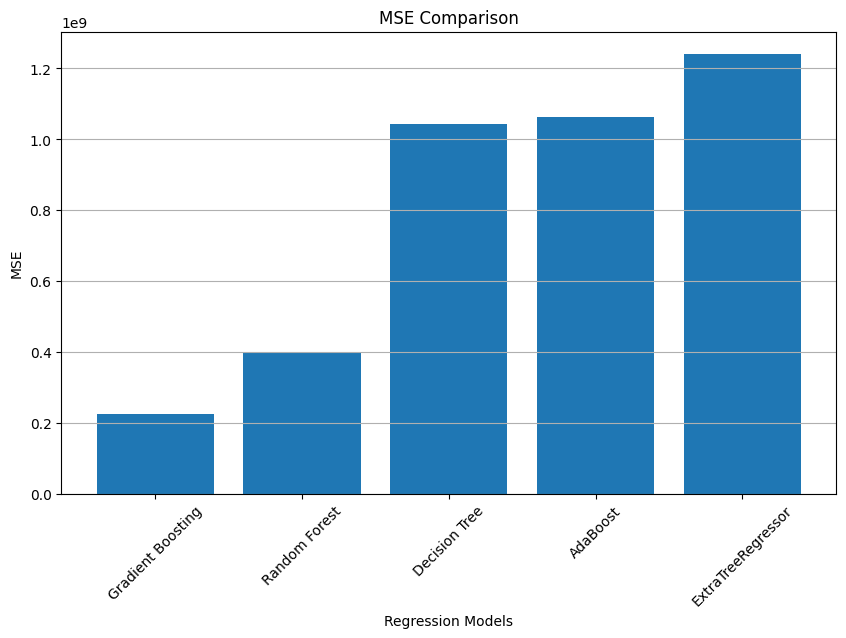

In [34]:
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["MSE"])
plt.title("MSE Comparison")
plt.xlabel("Regression Models")
plt.ylabel("MSE")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

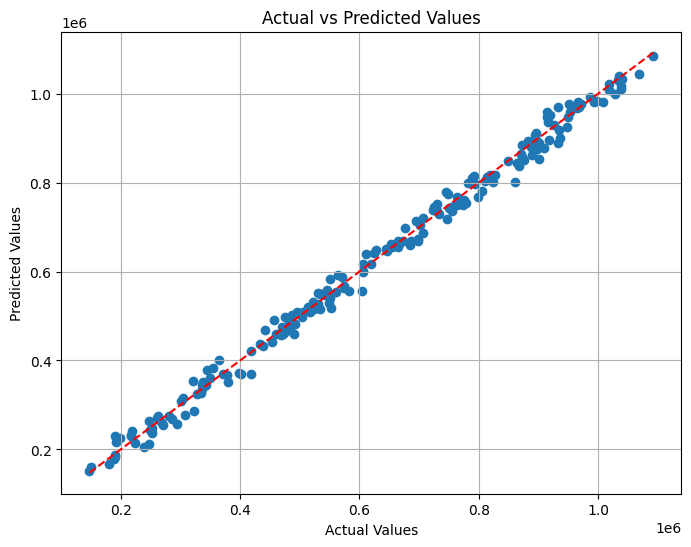

In [40]:
# Example: Random Forest
best_model = RandomForestRegressor(random_state=42)
best_model.fit(x_train, y_train)
y_pred = best_model.predict(x_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.grid(True)
plt.show()